In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df = pd.read_csv('hotel_booking.csv')

# İlk 5 satıra bakarak veriyi kontrol et
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.0,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498


In [12]:
# Eksik verileri kontrol et
missing_values = df.isnull().sum()

# Sadece eksik veri olan sütunları filtrele 
missing_only = missing_values[missing_values > 0]

print("Eksik veri bulunan sütunlar ve miktarları:")
print(missing_only)

print("\nToplam satır sayısı:", len(df))


Eksik veri bulunan sütunlar ve miktarları:
children         4
country        488
agent        16340
company     112593
dtype: int64

Toplam satır sayısı: 119390


In [13]:
# 1. 'company' sütununu tamamen sil
df.drop(columns=['company'], inplace=True)

# 2. 'children' sütunundaki 4 boşluğu 0 ile doldur
df['children'] = df['children'].fillna(0)

# 3. 'country' sütunundaki boşluklara "Unknown" yaz
df['country'] = df['country'].fillna('Unknown')

remaining_nulls = df[['children', 'country']].isnull().sum()
column_exists = 'company' in df.columns

print("Kalan eksik veriler:")
print(remaining_nulls)
print(f"\n'company' sütunu hala var mı?: {column_exists}")
print(f"Yeni veri seti boyutu: {df.shape}")

Kalan eksik veriler:
children    0
country     0
dtype: int64

'company' sütunu hala var mı?: False
Yeni veri seti boyutu: (119390, 35)


In [14]:
#Keşifçi veri analizi EDA
# 1. İptal Oranlarını Hesapla
cancellation_rates = df['is_canceled'].value_counts(normalize=True) * 100 ##is_canceled sütunundaki verilere göre alındı
print("Rezervasyon İptal Oranları (%):")
print(cancellation_rates)
#kullanılan datasetinfe 0: iptal edilmeyen rezervasyonlar, 1:iptal edilen rzervasyonlar

Rezervasyon İptal Oranları (%):
is_canceled
0    62.958372
1    37.041628
Name: proportion, dtype: float64


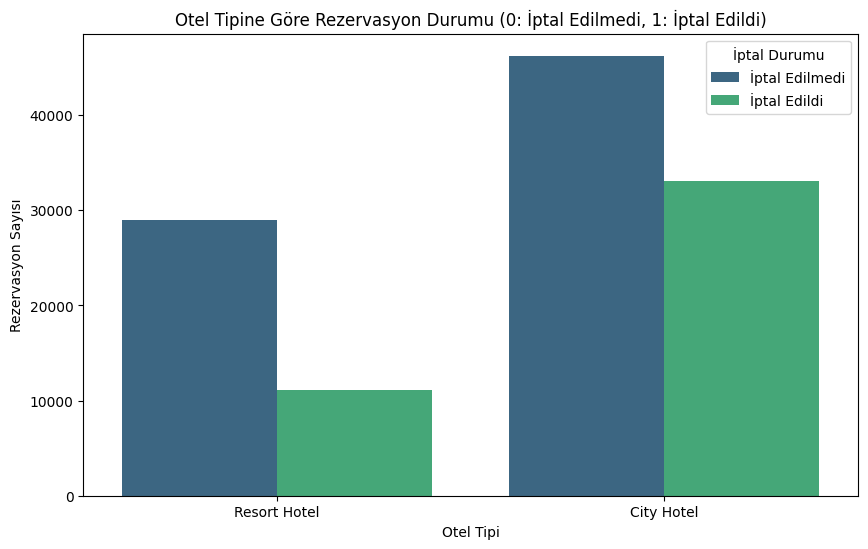

In [15]:
# 2. Görselleştirme: Otel Tipine Göre İptal Durumu
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='hotel', hue='is_canceled', palette='viridis') #viridis ; renk haritası(paleti)
plt.title('Otel Tipine Göre Rezervasyon Durumu (0: İptal Edilmedi, 1: İptal Edildi)')
plt.xlabel('Otel Tipi')
plt.ylabel('Rezervasyon Sayısı')
plt.legend(title='İptal Durumu', labels=['İptal Edilmedi', 'İptal Edildi'])

In [16]:
sıra = ["January", "February", "March", "April", "May", "June", 
                  "July", "August", "September", "October", "November", "December"]

# 1. Aylara göre doluluk (İptal edilmeyen rezervasyon sayısı) - Çizgi Grafik
resort_hotel = df[(df['hotel'] == 'Resort Hotel') & (df['is_canceled'] == 0)]
city_hotel = df[(df['hotel'] == 'City Hotel') & (df['is_canceled'] == 0)]

resort_monthly = resort_hotel['arrival_date_month'].value_counts().reindex(sıra)
city_monthly = city_hotel['arrival_date_month'].value_counts().reindex(sıra)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, 'January'),
  Text(1, 0, 'February'),
  Text(2, 0, 'March'),
  Text(3, 0, 'April'),
  Text(4, 0, 'May'),
  Text(5, 0, 'June'),
  Text(6, 0, 'July'),
  Text(7, 0, 'August'),
  Text(8, 0, 'September'),
  Text(9, 0, 'October'),
  Text(10, 0, 'November'),
  Text(11, 0, 'December')])

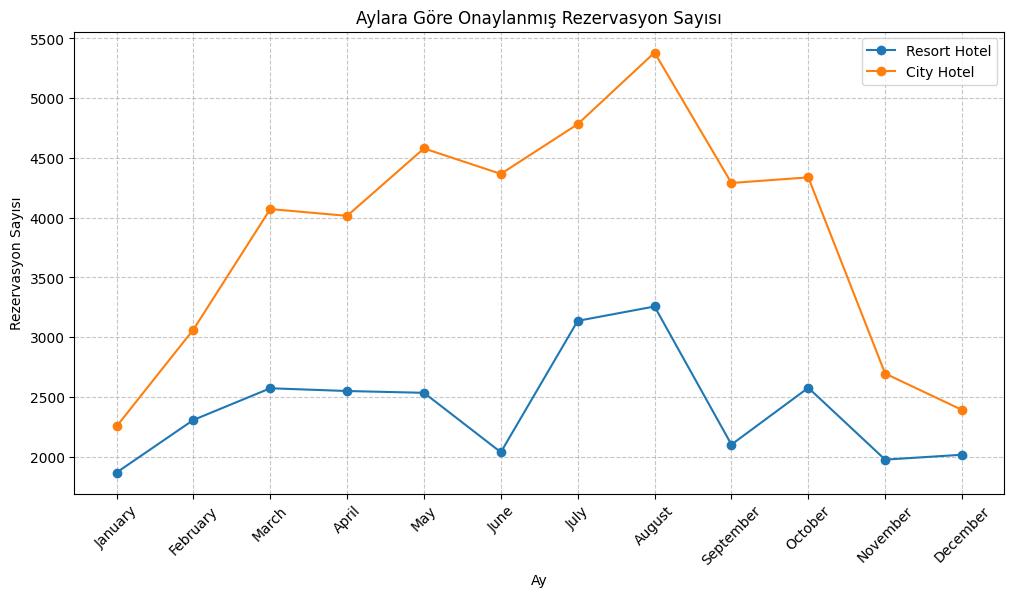

In [17]:
plt.figure(figsize=(12, 6))
plt.plot(resort_monthly.index, resort_monthly.values, label='Resort Hotel', marker='o')
plt.plot(city_monthly.index, city_monthly.values, label='City Hotel', marker='o')
plt.title('Aylara Göre Onaylanmış Rezervasyon Sayısı')
plt.xlabel('Ay')
plt.ylabel('Rezervasyon Sayısı')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)

In [19]:
country_map = {
    'PRT': 'Portekiz',
    'GBR': 'Birleşik Krallık',
    'FRA': 'Fransa',
    'ESP': 'İspanya',
    'DEU': 'Almanya',
    'ITA': 'İtalya',
    'IRL': 'İrlanda',
    'BEL': 'Belçika',
    'BRA': 'Brezilya',
    'NLD': 'Hollanda'
}

top_countries = df['country'].value_counts().head(10)
top_countries_named = top_countries.copy()
top_countries_named.index = [country_map.get(code, code) for code in top_countries.index]

C:\Users\Hp\AppData\Local\Temp\ipykernel_28412\3164580223.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries_named.index, y=top_countries_named.values, palette='plasma')


Text(0, 0.5, 'Rezervasyon Sayısı')

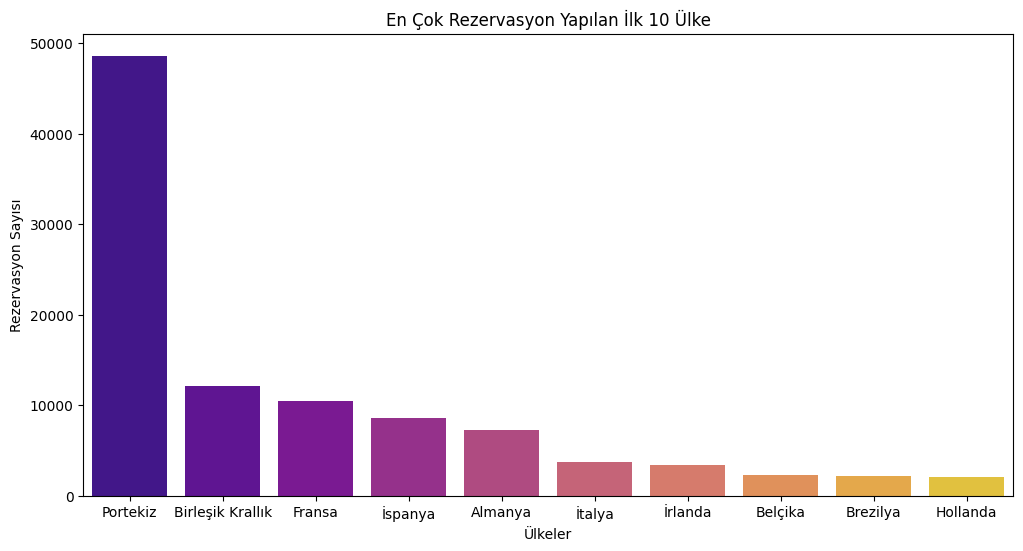

In [20]:
# Ülkelere Göre Müşteri Sayısı (Top 10) - Bar Grafik
plt.figure(figsize=(12, 6))
sns.barplot(x=top_countries_named.index, y=top_countries_named.values, palette='plasma')
plt.title('En Çok Rezervasyon Yapılan İlk 10 Ülke')
plt.xlabel('Ülkeler')
plt.ylabel('Rezervasyon Sayısı')


Portekiz vs Diğer Ülkeler Analizi:

Ortalama Fiyatlar:
is_portugal
Diğer Ülkeler    108.549745
Portekiz          92.041483
Name: adr, dtype: float64


C:\Users\Hp\AppData\Local\Temp\ipykernel_28412\2868298400.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_adr.index, y=avg_adr.values, palette='plasma')


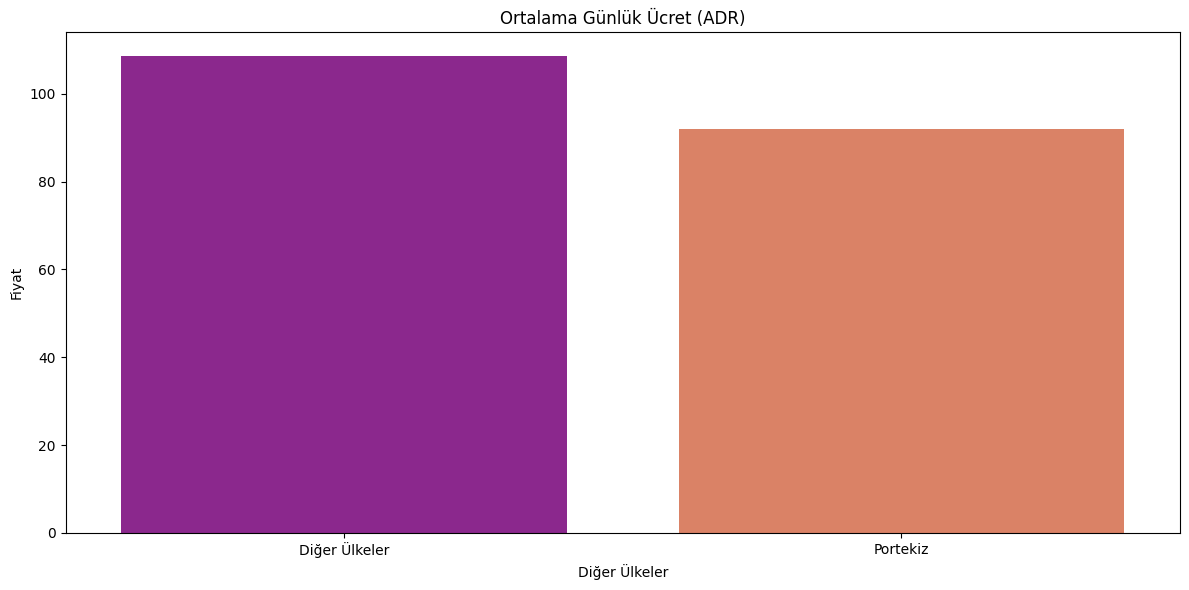

In [21]:
# Portekiz (PRT) ve Diğer Ülkeler olarak ikiye ayrıldı
df['is_portugal'] = df['country'].apply(lambda x: 'Portekiz' if x == 'PRT' else 'Diğer Ülkeler')

# Ortalama Fiyat (ADR)
avg_adr = df.groupby('is_portugal')['adr'].mean()


plt.figure(figsize=(12, 6))
sns.barplot(x=avg_adr.index, y=avg_adr.values, palette='plasma')
plt.title('Ortalama Günlük Ücret (ADR)')
plt.xlabel('Diğer Ülkeler')
plt.ylabel('Fiyat')

plt.tight_layout()

print("Portekiz vs Diğer Ülkeler Analizi:")
print("\nOrtalama Fiyatlar:")
print(avg_adr)


In [27]:
def ulke_onerisi_yap(max_butce, otel_tipi):
    #  Kullanıcının seçtiği otel tipine göre filtrele ve iptal edilmemiş olanları al
    filtre = df[(df['hotel'] == otel_tipi) & (df['is_canceled'] == 0)]
    
    # Ülke bazında ortalama fiyatları (ADR) hesapla
    ulke_fiyatlari = filtre.groupby('country')['adr'].mean().reset_index()
    
    # Kullanıcının bütçesine uyan ülkeleri bul
    uygun_ulkeler = ulke_fiyatlari[ulke_fiyatlari['adr'] <= max_butce].sort_values(by='adr', ascending=False)
    
    if uygun_ulkeler.empty:
        return "Üzgünüm, bu bütçeye uygun bir ülke bulunamadı."
    else:
        # En iyi 3 öneriyi döndür
        return uygun_ulkeler.head(3)

# KULLANICI GİRİŞİ
butce = float(input("Günlük maksimum bütçeniz nedir? (Örn: 100): "))
secim = input("Hangi otel tipini istersiniz? (City Hotel / Resort Hotel): ")

oneriler = ulke_onerisi_yap(butce, secim)
print(f"\nBütçenize uygun en popüler {secim} önerileri:")
print(oneriler)


Bütçenize uygun en popüler Resort Hotel önerileri:
   country    adr
2      AND  295.0
33     DJI  273.0
86     PER  234.0
